# Lab 2 — Gradient descent principles

This notebook solves the laboratory *Gradient descent principles* (unconstrained optimization of a function $f(\mathbf{x})$, $\mathbf{x}\in\mathbb{R}^2$). It is organised exactly like the statement:

1. **Gradient descent methods**
   1. A simple quadratic function $f(\mathbf{x}) = x_1^2 + x_2^2$ (constant step).
   2. A function with multiple minima (constant step vs. backtracking step).
   3. The Rosenbrock function (backtracking gradient descent on a badly scaled problem).
2. **Newton descent method**
   1. A badly scaled quadratic $f(\mathbf{x}) = 100x_1^2 + x_2^2$ (gradient vs. Newton).
   2. The multiple-minima function (hybrid Newton / gradient method).
   3. The Rosenbrock function (hybrid Newton / gradient method).
3. **Conclusions**

Every experiment is followed by a short markdown cell that interprets the results and answers the questions asked in the statement.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"figure.dpi": 90, "axes.grid": False})

## 0. Common tools

All the experiments share the same building blocks, so we write them once:

* **Objective functions** together with their **analytical gradients** (and Hessians, needed later for Newton).
* `gd_constant` — gradient descent with a constant step, $\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha\,\nabla f(\mathbf{x}_k)$.
* `backtracking` — the inner loop of Figure 1 in the statement: start with $\alpha_k = 1$ and halve it until $f(\mathbf{x}_k + \alpha_k \mathbf{d}_k) < f(\mathbf{x}_k)$.
* `descent` — the outer loop. It moves along a direction $\mathbf{d}_k$ that is either $-\nabla f(\mathbf{x}_k)$ (gradient descent) or the Newton direction, solution of $\nabla^2 f(\mathbf{x}_k)\,\mathbf{d}_k = -\nabla f(\mathbf{x}_k)$, used **only when the Hessian is positive definite** (Section 2.2). It stops when $\|\nabla f(\mathbf{x}_k)\| < 10^{-5}$ or, optionally, when $|f(\mathbf{x}_{k+1}) - f(\mathbf{x}_k)| < $ `ftol`. It records the path, the method used at each iteration and the number of function evaluations, so that comparisons are fair.

In [2]:
# ---------- 1.1  f(x) = x1^2 + x2^2 ----------
def f_quad(x):  return x[0]**2 + x[1]**2
def g_quad(x):  return np.array([2*x[0], 2*x[1]])

# ---------- 1.2  multiple minima ("six-hump camel" function) ----------
def f_camel(x):
    x1, x2 = x
    return x1**2*(4 - 2.1*x1**2 + x1**4/3) + x1*x2 + x2**2*(-4 + 4*x2**2)

def g_camel(x):
    x1, x2 = x
    return np.array([8*x1 - 8.4*x1**3 + 2*x1**5 + x2,
                     x1 - 8*x2 + 16*x2**3])

def h_camel(x):
    x1, x2 = x
    return np.array([[8 - 25.2*x1**2 + 10*x1**4, 1.0],
                     [1.0, -8 + 48*x2**2]])

# ---------- 1.3  Rosenbrock, a = 1, b = 100 ----------
a, b = 1.0, 100.0
def f_rosen(x): return (a - x[0])**2 + b*(x[1] - x[0]**2)**2

def g_rosen(x):
    return np.array([-2*(a - x[0]) - 4*b*x[0]*(x[1] - x[0]**2),
                     2*b*(x[1] - x[0]**2)])

def h_rosen(x):
    return np.array([[2 - 4*b*(x[1] - x[0]**2) + 8*b*x[0]**2, -4*b*x[0]],
                     [-4*b*x[0],                                2*b      ]])

# ---------- 2.1  badly scaled quadratic ----------
def f_ill(x):  return 100*x[0]**2 + x[1]**2
def g_ill(x):  return np.array([200*x[0], 2*x[1]])
def h_ill(x):  return np.array([[200.0, 0.0], [0.0, 2.0]])

Before using the analytical derivatives, it is good practice to check them against finite differences (a wrong gradient is the most common bug in this kind of lab).

In [3]:
def num_grad(f, x, h=1e-6):
    e = np.eye(len(x))
    return np.array([(f(x + h*ei) - f(x - h*ei)) / (2*h) for ei in e])

def num_hess(g, x, h=1e-6):
    e = np.eye(len(x))
    return np.array([(g(x + h*ei) - g(x - h*ei)) / (2*h) for ei in e]).T

rng = np.random.default_rng(0)
for name, f, g, H in [("quad", f_quad, g_quad, None), ("camel", f_camel, g_camel, h_camel),
                      ("rosen", f_rosen, g_rosen, h_rosen), ("ill", f_ill, g_ill, h_ill)]:
    x = rng.uniform(-1.5, 1.5, 2)
    err_g = np.abs(num_grad(f, x) - g(x)).max()
    err_h = np.abs(num_hess(g, x) - H(x)).max() if H else 0.0
    print(f"{name:6s}  max|grad error| = {err_g:.2e}   max|Hessian error| = {err_h:.2e}")

quad    max|grad error| = 3.54e-11   max|Hessian error| = 0.00e+00
camel   max|grad error| = 2.20e-09   max|Hessian error| = 9.14e-09
rosen   max|grad error| = 5.25e-09   max|Hessian error| = 2.72e-08
ill     max|grad error| = 2.15e-09   max|Hessian error| = 4.02e-09


In [4]:
def gd_constant(grad, x0, alpha, n_iter=100):
    # Gradient descent with a constant step. Returns the full path (n_iter+1 points).
    x = np.array(x0, dtype=float)
    path = [x.copy()]
    for _ in range(n_iter):
        x = x - alpha * grad(x)
        path.append(x.copy())
    return np.array(path)


def backtracking(f, x, d, fx=None, alpha0=1.0, alpha_min=1e-14):
    # Inner loop of Fig. 1: start with alpha = 1 and halve it until f decreases.
    # Returns (alpha, number_of_function_evaluations). alpha = 0 means 'no decrease found'.
    fx = f(x) if fx is None else fx
    alpha, nfev = alpha0, 0
    while True:
        nfev += 1
        if f(x + alpha * d) < fx:
            return alpha, nfev
        alpha /= 2
        if alpha < alpha_min:
            return 0.0, nfev


def descent(f, grad, x0, hess=None, tol=1e-5, ftol=None, max_iter=100_000):
    # Outer loop.
    #   hess is None -> pure gradient descent with backtracking.
    #   hess given   -> hybrid method: Newton direction if the Hessian is positive
    #                   definite, gradient direction otherwise (Section 2.2).
    # Stops when ||grad f|| < tol, or |f(x_{k+1}) - f(x_k)| < ftol (if ftol is given),
    # or when no decrease can be obtained, or after max_iter iterations.
    x = np.array(x0, dtype=float)
    fx = f(x)
    path, methods, alphas, nfev = [x.copy()], [], [], 1
    for k in range(max_iter):
        g = grad(x)
        if np.linalg.norm(g) < tol:
            break
        d, used = -g, "GD"
        if hess is not None:
            H = hess(x)
            if np.all(np.linalg.eigvalsh(H) > 0):          # positive definite?
                d, used = np.linalg.solve(H, -g), "Newton"
        alpha, ne = backtracking(f, x, d, fx)
        nfev += ne
        if alpha == 0.0:
            break
        x_new = x + alpha * d
        f_new = f(x_new)
        stop_f = ftol is not None and abs(f_new - fx) < ftol
        x, fx = x_new, f_new
        path.append(x.copy()); methods.append(used); alphas.append(alpha)
        if stop_f:
            break
    return dict(x=x, f=fx, path=np.array(path), methods=methods, alphas=np.array(alphas),
                iters=len(path) - 1, nfev=nfev, grad_norm=np.linalg.norm(grad(x)))

In [5]:
def contour(f, xlim, ylim, levels=30, ax=None, n=400, log=False, quiver_grad=None, qn=20, normalize=False):
    # Contour plot of f on [xlim] x [ylim]; optionally draws the gradient field.
    ax = ax or plt.gca()
    X, Y = np.meshgrid(np.linspace(*xlim, n), np.linspace(*ylim, n))
    Z = f(np.array([X, Y]))
    if log:
        cs = ax.contour(X, Y, Z, levels=np.logspace(-1, np.log10(Z.max()), levels), cmap="viridis",
                        linewidths=0.8)
    else:
        cs = ax.contour(X, Y, Z, levels=levels, cmap="viridis", linewidths=0.8)
    if quiver_grad is not None:
        Xq, Yq = np.meshgrid(np.linspace(*xlim, qn), np.linspace(*ylim, qn))
        G = quiver_grad(np.array([Xq, Yq]))
        U, V = G[0], G[1]
        if normalize:
            N = np.hypot(U, V) + 1e-12
            U, V = U / N, V / N
        ax.quiver(Xq, Yq, U, V, color="tab:red", alpha=0.6, width=0.003)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    return cs


def draw_path(path, ax=None, color="k", label=None, ms=3):
    ax = ax or plt.gca()
    ax.plot(path[:, 0], path[:, 1], "-o", color=color, ms=ms, lw=1, label=label)
    ax.plot(*path[0], "s", color=color, ms=7)               # start: square
    ax.plot(*path[-1], "*", color=color, ms=12, mec="k")     # end: star


def draw_methods(res, ax=None):
    # Hybrid method path: green dots = Newton step, red dots = gradient step.
    ax = ax or plt.gca()
    P = res["path"]
    ax.plot(P[:, 0], P[:, 1], "-", color="gray", lw=0.8)
    for i, m in enumerate(res["methods"]):
        ax.plot(*P[i], "o", color="green" if m == "Newton" else "red", ms=5)
    ax.plot(*P[-1], "*", color="gold", ms=14, mec="k")


method_legend = [Line2D([], [], marker="o", ls="", color="green", label="Newton step"),
                 Line2D([], [], marker="o", ls="", color="red", label="Gradient step"),
                 Line2D([], [], marker="*", ls="", color="gold", mec="k", ms=12, label="final point")]
colors = plt.cm.tab10.colors

---
# 1. Gradient descent methods

## 1.1 A simple quadratic function

$$f(\mathbf{x}) = x_1^2 + x_2^2, \qquad \nabla f(\mathbf{x}) = (2x_1,\ 2x_2)^T .$$

This function is convex (its Hessian is $2I$, positive definite), so it has a single minimum at $\mathbf{x}^* = (0,0)$.

First we reproduce the example of the statement: a contour plot of $f$ together with its gradient field.

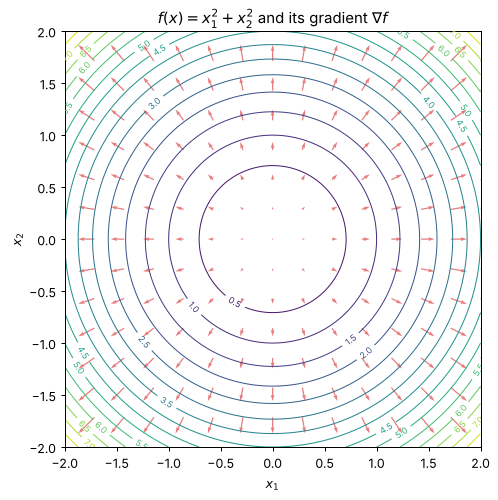

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))
cs = contour(f_quad, (-2, 2), (-2, 2), levels=15, ax=ax, quiver_grad=g_quad, qn=15)
ax.clabel(cs, fontsize=7)
ax.set_title(r"$f(x)=x_1^2+x_2^2$ and its gradient $\nabla f$")
ax.set_aspect("equal")
plt.show()

**Observation.** The arrows are perpendicular to the level curves and point **outwards**, i.e. towards the direction in which $f$ increases fastest; their length grows with the distance to the origin because $\|\nabla f\| = 2\|\mathbf{x}\|$. To minimize, we therefore move in the **opposite** direction, $-\nabla f$, which here points straight to the minimum. This is the gradient descent iteration

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha_k \nabla f(\mathbf{x}_k).$$

### Experiment 1 — constant step $\alpha_k = 0.1$, 100 iterations, several starting points

              x0 |                        x_100 |   f(x_100)
      (1.8, 1.5) |                      [0. 0.] |   2.28e-19
     (-1.7, 0.6) |                    [-0.  0.] |   1.35e-19
    (-1.0, -1.8) |                    [-0. -0.] |   1.76e-19
     (1.5, -1.2) |                    [ 0. -0.] |   1.53e-19
      (0.3, 1.9) |                      [0. 0.] |   1.54e-19


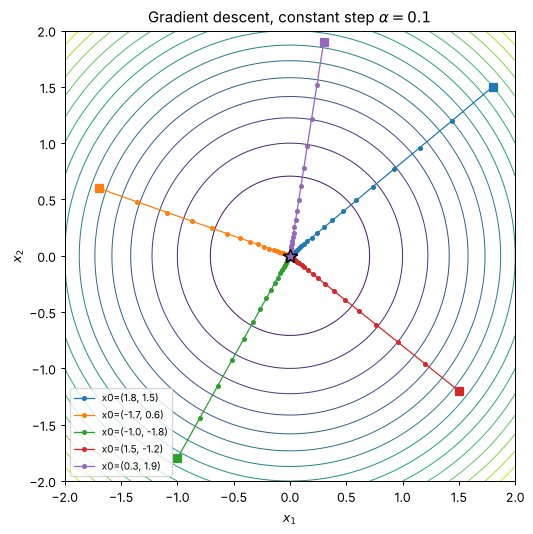

In [7]:
starts_q = [(1.8, 1.5), (-1.7, 0.6), (-1.0, -1.8), (1.5, -1.2), (0.3, 1.9)]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
contour(f_quad, (-2, 2), (-2, 2), levels=15, ax=ax)
print(f"{'x0':>16s} | {'x_100':>28s} | {'f(x_100)':>10s}")
for i, x0 in enumerate(starts_q):
    P = gd_constant(g_quad, x0, alpha=0.1, n_iter=100)
    draw_path(P, ax, color=colors[i], label=f"x0={x0}")
    print(f"{str(x0):>16s} | {str(P[-1]):>28s} | {f_quad(P[-1]):10.2e}")
ax.set_aspect("equal"); ax.legend(fontsize=8, loc="lower left")
ax.set_title(r"Gradient descent, constant step $\alpha=0.1$")
plt.show()

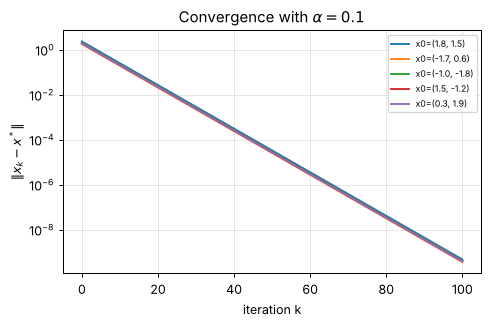

In [8]:
# Distance to the minimum versus iteration
plt.figure(figsize=(6, 3.5))
for i, x0 in enumerate(starts_q):
    P = gd_constant(g_quad, x0, alpha=0.1, n_iter=100)
    plt.semilogy(np.linalg.norm(P, axis=1), color=colors[i], label=f"x0={x0}")
plt.xlabel("iteration k"); plt.ylabel(r"$\|x_k - x^*\|$")
plt.title(r"Convergence with $\alpha = 0.1$"); plt.legend(fontsize=7); plt.grid(alpha=.3)
plt.show()

**Answer / interpretation.**

* For **every** starting point the algorithm converges to the only minimum $(0,0)$: after 100 iterations the points are at a distance of order $10^{-10}$ from it and $f(\mathbf{x}_{100})\approx 10^{-19}$.
* The paths are **straight lines** towards the origin: for this function $-\nabla f(\mathbf{x}) = -2\mathbf{x}$ points exactly at the minimum.
* The more iterations, the closer to the minimum. In fact we can compute the iteration in closed form:
$$\mathbf{x}_{k+1} = \mathbf{x}_k - 0.1\cdot 2\mathbf{x}_k = 0.8\,\mathbf{x}_k \quad\Longrightarrow\quad \mathbf{x}_k = 0.8^k\,\mathbf{x}_0 ,$$
so the error shrinks by a constant factor 0.8 per iteration (linear convergence — the straight lines in the semilog plot all have the same slope $\log 0.8$). The successive points also get closer to each other, because the step $\alpha\|\nabla f\|$ is proportional to the gradient, which vanishes at the minimum.

### Experiment 2 — larger steps: $\alpha_k = 1$ and $\alpha_k = 2$

alpha = 0.1:  x_1..x_4 = [[1.2, -0.8], [0.96, -0.64], [0.768, -0.512], [0.614, -0.41]]   x_100 = [ 0. -0.]
alpha = 1.0:  x_1..x_4 = [[-1.5, 1.0], [1.5, -1.0], [-1.5, 1.0], [1.5, -1.0]]   x_100 = [ 1.5 -1. ]
alpha = 2.0:  x_1..x_4 = [[-4.5, 3.0], [13.5, -9.0], [-40.5, 27.0], [121.5, -81.0]]   x_100 = [ 7.730663e+47 -5.153775e+47]


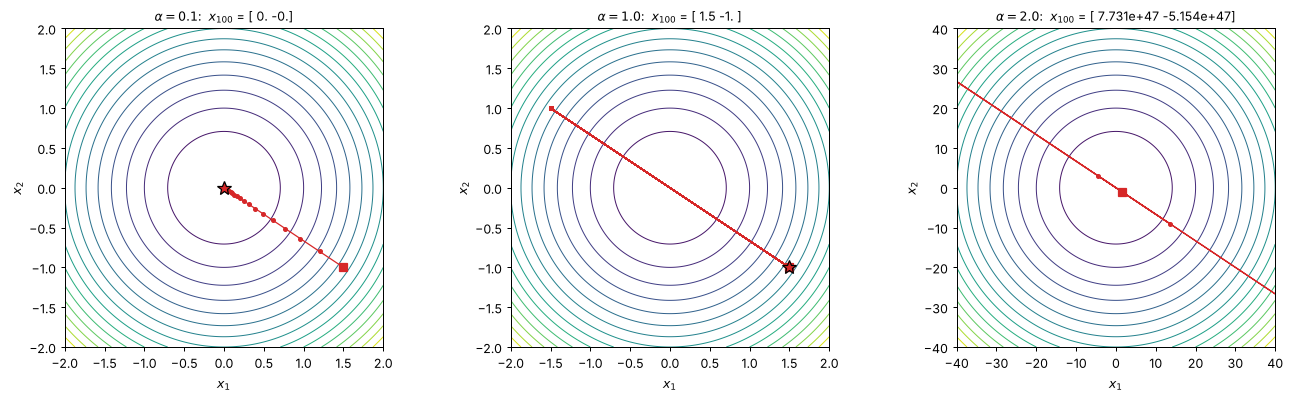

In [9]:
x0 = (1.5, -1.0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, alpha in zip(axes, [0.1, 1.0, 2.0]):
    P = gd_constant(g_quad, x0, alpha=alpha, n_iter=100)
    lim = 2 if alpha < 2 else 40
    contour(f_quad, (-lim, lim), (-lim, lim), levels=15, ax=ax)
    draw_path(P[:6] if alpha == 2 else P, ax, color="tab:red")
    ax.set_aspect("equal")
    ax.set_title(rf"$\alpha={alpha}$:  $x_{{100}}$ = {np.array2string(P[-1], precision=3)}", fontsize=10)
    print(f"alpha = {alpha}:  x_1..x_4 = {P[1:5].round(3).tolist()}   x_100 = {P[-1]}")
plt.tight_layout(); plt.show()

**Answer / interpretation.**

* $\alpha = 1$: $\mathbf{x}_{k+1} = \mathbf{x}_k - 2\mathbf{x}_k = -\mathbf{x}_k$. The iterates **bounce forever** between $\mathbf{x}_0$ and $-\mathbf{x}_0$; the step jumps over the minimum to the symmetric point on the same level curve and $f$ never decreases.
* $\alpha = 2$: $\mathbf{x}_{k+1} = -3\mathbf{x}_k$. Each step overshoots so much that the point lands on a *higher* level curve: the iteration **diverges** ($\|\mathbf{x}_{100}\| \approx 3^{100}\|\mathbf{x}_0\|\sim 10^{47}$).

In general for this function $\mathbf{x}_{k+1} = (1-2\alpha)\mathbf{x}_k$, so gradient descent converges **iff** $|1-2\alpha|<1$, i.e. $0<\alpha<1$; the best possible constant step is $\alpha = 0.5$, which reaches the minimum in one iteration. This shows how important the choice of the step $\alpha$ is: too small means slow progress, too large means oscillation or divergence. For a general function the "right" $\alpha$ is unknown (it depends on the curvature, i.e. on the Hessian), which motivates choosing $\alpha_k$ adaptively at every iteration (Section 1.2).

---
## 1.2 A function with multiple minima

$$f(x_1,x_2) = x_1^2\left(4 - 2.1x_1^2 + \tfrac13 x_1^4\right) + x_1x_2 + x_2^2\left(-4+4x_2^2\right)$$

(the classic *six-hump camel* test function). Its gradient is

$$\nabla f = \begin{pmatrix} 8x_1 - 8.4x_1^3 + 2x_1^5 + x_2 \\ x_1 - 8x_2 + 16x_2^3\end{pmatrix}.$$

### Contour plot in $x_1\in[-2,2]$, $x_2\in[-1,1]$

In [10]:
# Locate all stationary points numerically (Newton on grad f = 0 from a grid), and classify them
cands = []
for s1 in np.linspace(-2, 2, 21):
    for s2 in np.linspace(-1, 1, 11):
        x = np.array([s1, s2])
        for _ in range(50):
            try: x = x - np.linalg.solve(h_camel(x), g_camel(x))
            except np.linalg.LinAlgError: break
        if np.linalg.norm(g_camel(x)) < 1e-10 and abs(x[0]) <= 2 and abs(x[1]) <= 1:
            if not any(np.allclose(x, c, atol=1e-6) for c in cands):
                cands.append(x)
stat = sorted(cands, key=f_camel)
minima = []
print(f"{'point':>24s} {'f':>9s}   type")
for x in stat:
    ev = np.linalg.eigvalsh(h_camel(x))
    kind = "minimum" if np.all(ev > 0) else ("maximum" if np.all(ev < 0) else "saddle")
    if kind == "minimum": minima.append(x)
    print(f"{str(x.round(4)):>24s} {f_camel(x):9.4f}   {kind}")
minima = np.array(minima)

                   point         f   type
       [-0.0898  0.7127]   -1.0316   minimum
       [ 0.0898 -0.7127]   -1.0316   minimum
       [-1.7036  0.7961]   -0.2155   minimum
       [ 1.7036 -0.7961]   -0.2155   minimum
                 [0. 0.]    0.0000   saddle
       [-1.1092  0.7683]    0.5437   saddle
       [ 1.1092 -0.7683]    0.5437   saddle
       [-1.6071 -0.5687]    2.1043   minimum
         [1.6071 0.5687]    2.1043   minimum
       [-1.6381 -0.2287]    2.2294   saddle
         [1.6381 0.2287]    2.2294   saddle
       [-1.2961 -0.6051]    2.2295   saddle
         [1.2961 0.6051]    2.2295   saddle
       [-1.2302 -0.1623]    2.4963   maximum
         [1.2302 0.1623]    2.4963   maximum


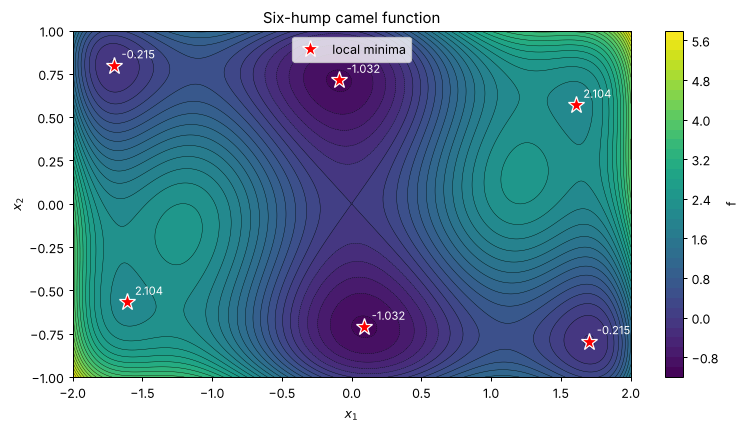

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
X, Y = np.meshgrid(np.linspace(-2, 2, 400), np.linspace(-1, 1, 200))
Z = f_camel(np.array([X, Y]))
cf = ax.contourf(X, Y, Z, levels=40, cmap="viridis")
ax.contour(X, Y, Z, levels=40, colors="k", linewidths=0.3)
plt.colorbar(cf, ax=ax, label="f")
ax.plot(minima[:, 0], minima[:, 1], "r*", ms=14, mec="w", label="local minima")
for m in minima:
    ax.annotate(f"{f_camel(m):.3f}", m, textcoords="offset points", xytext=(6, 6), color="w", fontsize=9)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.legend(loc="upper center")
ax.set_title("Six-hump camel function"); plt.show()

The function is **not convex**. In the box $[-2,2]\times[-1,1]$ it has **six local minima** (symmetric two by two, because $f(-\mathbf{x}) = f(\mathbf{x})$):

* two **global** minima at $\approx(0.0898,-0.7127)$ and $(-0.0898,0.7127)$ with $f\approx-1.0316$;
* two local minima at $\approx(\pm1.7036,\mp0.7961)$ with $f\approx-0.2155$;
* two local minima at $\approx(\pm1.6071,\pm0.5687)$ with $f\approx 2.1043$;

plus saddle points (e.g. the origin) and local maxima separating the valleys. Which minimum gradient descent will find cannot be guessed in advance in general: it depends on the starting point $\mathbf{x}_0$.

### Experiment 1 — constant step $\alpha_k = 0.1$, 100 iterations

            x0 ->                  x_100   f(x_100)   ||grad||
  (-1.9, -0.9) ->      [ 0.0898 -0.7127]    -1.0316    1.8e-15
  (-1.5, -0.8) ->      [-1.6071 -0.5687]     2.1043    1.8e-15
   (-1.0, 0.0) ->      [-0.0898  0.7127]    -1.0316    1.8e-15
   (-0.5, 0.9) ->      [-0.0898  0.7127]    -1.0316    1.8e-15
    (0.0, 0.9) ->      [-0.0898  0.7127]    -1.0316    1.8e-15
   (0.1, -0.1) ->      [ 0.0898 -0.7127]    -1.0316    1.8e-15
    (0.5, 0.2) ->      [-0.0898  0.7127]    -1.0316    1.8e-15
   (1.0, -0.5) ->      [ 0.0898 -0.7127]    -1.0316    1.8e-15
    (1.5, 0.8) ->        [1.6071 0.5687]     2.1043    1.8e-15
    (1.9, 0.9) ->      [-0.0898  0.7127]    -1.0316    1.8e-15
   (-1.9, 0.9) ->      [-1.6221  0.9095]     0.0110    3.4e+00
  (1.9, -0.95) ->      [ 1.6221 -0.9095]     0.0110    3.4e+00


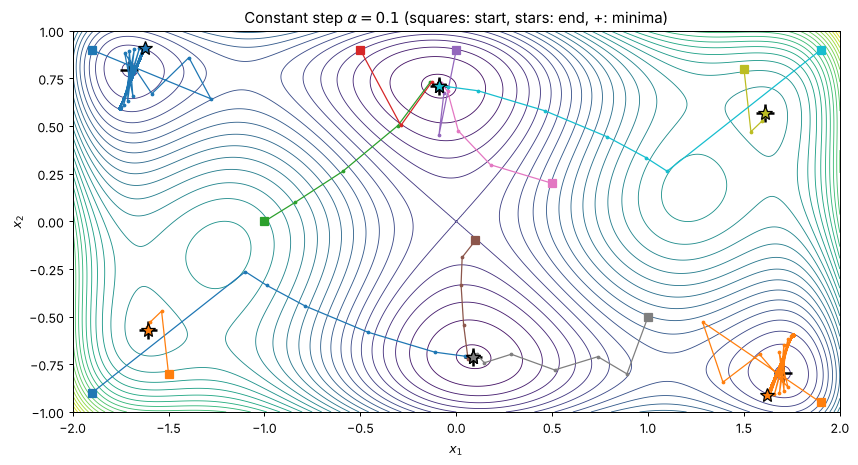

In [12]:
starts_c = [(-1.9, -0.9), (-1.5, -0.8), (-1.0, 0.0), (-0.5, 0.9), (0.0, 0.9),
            (0.1, -0.1), (0.5, 0.2), (1.0, -0.5), (1.5, 0.8), (1.9, 0.9), (-1.9, 0.9), (1.9, -0.95)]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.contour(X, Y, Z, levels=40, cmap="viridis", linewidths=0.7)
ax.plot(minima[:, 0], minima[:, 1], "k+", ms=14, mew=2)
const_res = {}
print(f"{'x0':>14s} -> {'x_100':>22s}  {'f(x_100)':>9s}  {'||grad||':>9s}")
for i, x0 in enumerate(starts_c):
    P = gd_constant(g_camel, x0, alpha=0.1, n_iter=100)
    const_res[x0] = P
    draw_path(P, ax, color=colors[i % 10], ms=2)
    print(f"{str(x0):>14s} -> {str(P[-1].round(4)):>22s}  {f_camel(P[-1]):9.4f}  {np.linalg.norm(g_camel(P[-1])):9.1e}")
ax.set_xlim(-2, 2); ax.set_ylim(-1, 1); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title(r"Constant step $\alpha = 0.1$ (squares: start, stars: end, +: minima)")
plt.show()

**Answer / interpretation.**

* For most starting points the run converges (gradient norm $\approx10^{-15}$ after 100 iterations) to **the minimum of the valley (basin of attraction) in which $\mathbf{x}_0$ lies**: the path goes "downhill", perpendicular to the level curves, and stops at the bottom of the first valley it reaches. Starting points in the outer valleys, e.g. $(-1.5,-0.8)$ and $(1.5,0.8)$, end at the local minima $(\mp1.6071,\mp0.5687)$ with $f\approx 2.10$, *not* at the global minimum; points starting in the central region, or whose path slides into it, end at one of the two global minima ($f\approx-1.03$). **Gradient descent is a local method**: it finds *a* local minimum, not necessarily the global one, and which one depends on $\mathbf{x}_0$.
* Two runs, from $(-1.9,0.9)$ and $(1.9,-0.95)$, **do not converge**: after 100 iterations they are stuck at $(\mp1.62,\pm0.91)$ with $\|\nabla f\|\approx3.4$, bouncing between two points. There the curvature in $x_2$ is large ($\partial^2 f/\partial x_2^2 = -8+48x_2^2\approx 31$), and a constant step only converges if $\alpha < 2/\lambda_{\max}\approx0.065$. The step $\alpha=0.1$ that was fine elsewhere is too large here — the same phenomenon we saw with $\alpha=1$ in Section 1.1. A single constant step cannot be adequate everywhere for a non-convex function, which motivates the adaptive step.

### Experiment 2 — adaptive step with backtracking

We now compute $\alpha_k$ at every iteration with the double loop of Figure 1 (function `backtracking` above): start with $\alpha_k=1$, halve it until $f(\mathbf{x}_k-\alpha_k\nabla f(\mathbf{x}_k))<f(\mathbf{x}_k)$, then update $\mathbf{x}$. We iterate until $\|\nabla f(\mathbf{x}_{k+1})\|<10^{-5}$ (no fixed number of iterations).

For a fair comparison, we also count how many iterations the constant-step method needs to satisfy the same criterion.

           x0 | const a=0.1: it                  x* | backtracking: it f-evals                  x*        f
 (-1.9, -0.9) |              19   [ 0.0898 -0.7127] |               11      43   [-0.0898  0.7127]  -1.0316
 (-1.5, -0.8) |              11   [-1.6071 -0.5687] |               15      73   [-1.7036  0.7961]  -0.2155
  (-1.0, 0.0) |              28   [-0.0898  0.7127] |               13      51   [ 0.0898 -0.7127]  -1.0316
  (-0.5, 0.9) |              26   [-0.0898  0.7127] |                8      36   [-0.0898  0.7127]  -1.0316
   (0.0, 0.9) |              27   [-0.0898  0.7127] |                9      42   [-0.0898  0.7127]  -1.0316
  (0.1, -0.1) |              28   [ 0.0898 -0.7127] |               10      43   [ 0.0898 -0.7127]  -1.0316
   (0.5, 0.2) |              28   [-0.0898  0.7127] |               16      65   [ 0.0898 -0.7127]  -1.0316
  (1.0, -0.5) |              30   [ 0.0898 -0.7127] |               10      43   [-0.0898  0.7127]  -1.0316
   (1.5, 0.8) |             

  (-1.9, 0.9) |          100000   [-1.6221  0.9095] |               12      52   [-0.0898  0.7127]  -1.0316


 (1.9, -0.95) |          100000   [ 1.6221 -0.9095] |               14      55   [-0.0898  0.7127]  -1.0316


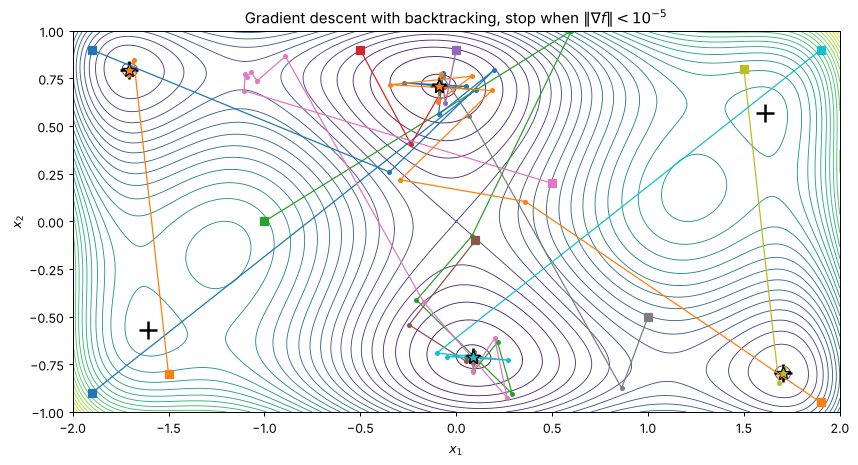

In [13]:
def iters_constant(grad, x0, alpha, tol=1e-5, max_iter=100_000):
    x = np.array(x0, float)
    for k in range(max_iter):
        if np.linalg.norm(grad(x)) < tol: return k, x
        x = x - alpha * grad(x)
    return max_iter, x

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.contour(X, Y, Z, levels=40, cmap="viridis", linewidths=0.7)
ax.plot(minima[:, 0], minima[:, 1], "k+", ms=14, mew=2)
bt_camel = {}
print(f"{'x0':>13s} | {'const a=0.1: it':>15s} {'x*':>19s} | {'backtracking: it':>16s} {'f-evals':>7s} {'x*':>19s} {'f':>8s}")
for i, x0 in enumerate(starts_c):
    kc, xc = iters_constant(g_camel, x0, 0.1)
    r = descent(f_camel, g_camel, x0)
    bt_camel[x0] = r
    draw_path(r["path"], ax, color=colors[i % 10], ms=3)
    print(f"{str(x0):>13s} | {kc:15d} {str(xc.round(4)):>19s} | {r['iters']:16d} {r['nfev']:7d} {str(r['x'].round(4)):>19s} {r['f']:8.4f}")
ax.set_xlim(-2, 2); ax.set_ylim(-1, 1); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title(r"Gradient descent with backtracking, stop when $\|\nabla f\|<10^{-5}$")
plt.show()

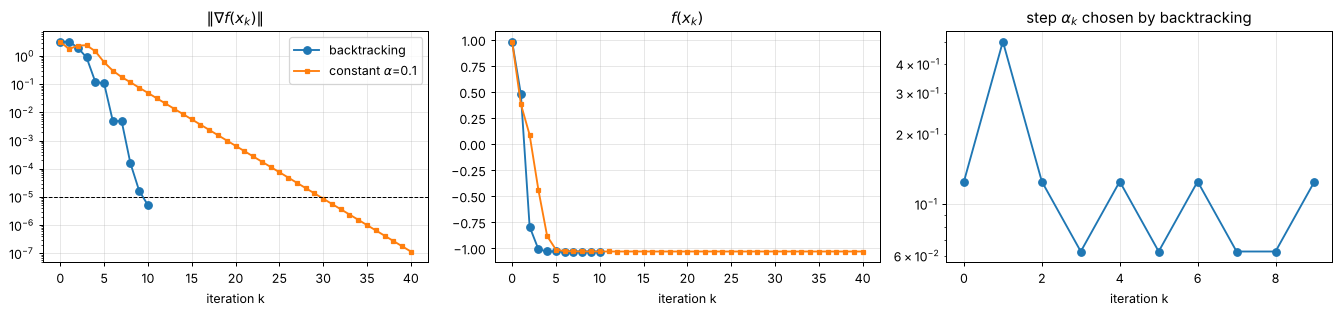

In [14]:
# A closer look at one run: step sizes chosen by backtracking and evolution of f and ||grad f||
x0 = (1.0, -0.5)
r = bt_camel[x0]
Pc = gd_constant(g_camel, x0, 0.1, n_iter=40)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].semilogy([np.linalg.norm(g_camel(p)) for p in r["path"]], "o-", label="backtracking")
axes[0].semilogy([np.linalg.norm(g_camel(p)) for p in Pc], "s-", ms=3, label=r"constant $\alpha$=0.1")
axes[0].axhline(1e-5, color="k", ls="--", lw=.8); axes[0].set_title(r"$\|\nabla f(x_k)\|$"); axes[0].legend()
axes[1].plot([f_camel(p) for p in r["path"]], "o-"); axes[1].plot([f_camel(p) for p in Pc], "s-", ms=3)
axes[1].set_title("$f(x_k)$")
axes[2].semilogy(r["alphas"], "o-"); axes[2].set_title(r"step $\alpha_k$ chosen by backtracking")
for a_ in axes: a_.set_xlabel("iteration k"); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

**Answer / interpretation — how does backtracking compare with the constant step?**

* **No step has to be tuned by hand.** The algorithm always starts with the "optimistic" step $\alpha_k=1$ and only reduces it when necessary, so it automatically adapts to the local curvature. By construction $f(\mathbf{x}_{k+1})<f(\mathbf{x}_k)$ at every iteration (monotone decrease), so it can never oscillate or diverge as happened with $\alpha=1$ or $\alpha=2$ in Section 1.1.
* **More robust.** From $(-1.9,0.9)$ and $(1.9,-0.95)$, where the constant step oscillates forever (100 000 iterations without converging), backtracking converges in 12–14 iterations.
* **Fewer iterations.** To reach $\|\nabla f\|<10^{-5}$ backtracking needs roughly **8–16 iterations**, against roughly **11–30** for the constant step $\alpha=0.1$ (when it converges); in both cases far fewer than 100. The accepted steps (right plot) are typically $\alpha_k\in\{1/8, 1/16\}$, i.e. *larger* than 0.1 where the function allows it. Note, however, that each backtracking iteration costs several function evaluations (column *f-evals*: 36–73 in total), so measured in total work the gain is small or even negative on this easy problem — the real benefit is robustness.
* **Which minimum?** The constant small step follows the steepest-descent path closely and stays in the valley of $\mathbf{x}_0$. The first trial steps of backtracking ($\alpha=1, 1/2, \dots$) can be very long, and the rule only asks for *some* decrease of $f$, so quite often the first accepted step **jumps into another valley**: e.g. from $(1.5,0.8)$ the constant step converges to the local minimum $(1.6071, 0.5687)$ ($f\approx2.10$) whereas backtracking lands in $(1.7036,-0.7961)$ ($f\approx-0.22$); from $(-1.0,0.0)$ or $(1.0,-0.5)$ both reach a global minimum, but not the same one of the two. This is neither good nor bad in itself: the algorithm is still local and the minimum found still depends on $\mathbf{x}_0$ (and now also on the step rule). Rules such as Armijo's (sufficient decrease) make the accepted steps more controlled.

There is no unique "number of iterations": it depends on the starting point and on the threshold, but in all cases tested it is well below 100.

---
## 1.3 The Rosenbrock function

$$f(x_1,x_2) = (a-x_1)^2 + b\,(x_2-x_1^2)^2,\qquad a=1,\ b=100,$$

$$\nabla f = \begin{pmatrix} -2(a-x_1) - 4b\,x_1(x_2-x_1^2) \\ 2b\,(x_2-x_1^2)\end{pmatrix}.$$

The global (and only) minimum is $\mathbf{x}^*=(a,a^2)=(1,1)$ with $f=0$. It lies at the bottom of a long, narrow, curved (parabolic) valley $x_2\approx x_1^2$.

### Experiment 1 — contour plot and gradient

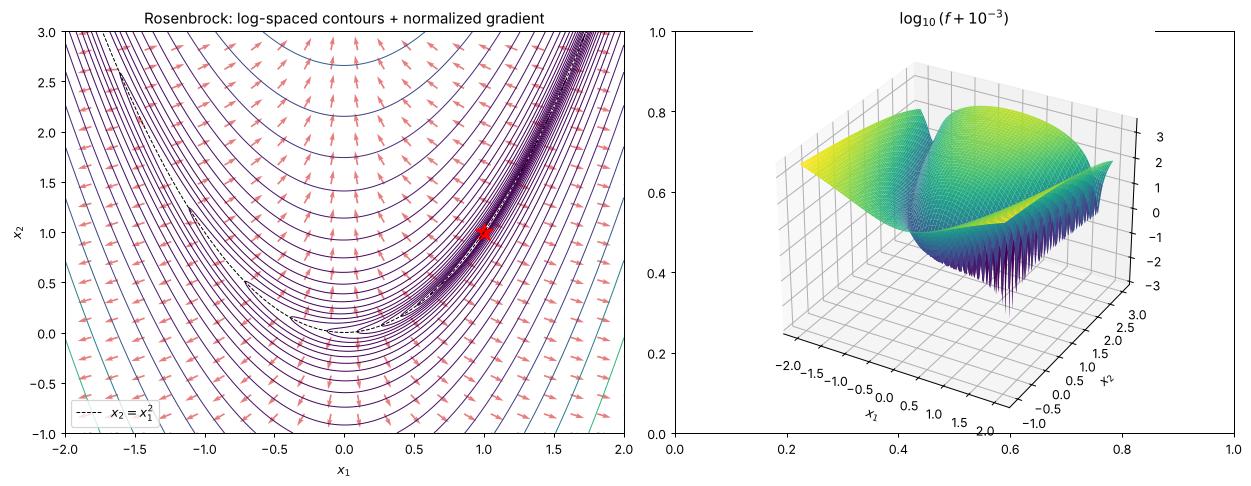

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
contour(f_rosen, (-2, 2), (-1, 3), levels=25, ax=axes[0], log=True, quiver_grad=g_rosen, qn=22, normalize=True)
axes[0].plot(1, 1, "r*", ms=15); axes[0].set_title("Rosenbrock: log-spaced contours + normalized gradient")
xs = np.linspace(-2, 2, 200); axes[0].plot(xs, xs**2, "k--", lw=.8, label="$x_2=x_1^2$"); axes[0].legend()

Xr, Yr = np.meshgrid(np.linspace(-2, 2, 300), np.linspace(-1, 3, 300))
Zr = f_rosen(np.array([Xr, Yr]))
axes[1] = fig.add_subplot(1, 2, 2, projection="3d")
axes[1].plot_surface(Xr, Yr, np.log10(Zr + 1e-3), cmap="viridis", lw=0, rstride=5, cstride=5)
axes[1].set_title(r"$\log_{10}(f+10^{-3})$"); axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
plt.tight_layout(); plt.show()

The (normalized) gradient arrows are almost **perpendicular to the valley** everywhere except at its very bottom: the term $b(x_2-x_1^2)^2$ with $b=100$ is much steeper than $(1-x_1)^2$. The direction of steepest descent therefore points to the bottom of the valley, *not along it* towards $(1,1)$. The function is badly scaled.

### Experiment 2 — backtracking gradient descent from several starting points

We keep running until $\|\nabla f(\mathbf{x}_{k+1})\|<10^{-5}$, without limiting the iterations to 100 (we set a safety cap of $10^5$).

In [16]:
starts_r = [(-1.5, 2.0), (-1.2, 1.0), (0.0, 0.0), (2.0, 2.0), (-1.0, -0.5), (0.0, 2.0)]
gd_rosen = {}
print(f"{'x0':>12s} | {'iterations':>10s} {'f-evals':>8s} | {'final x':>24s} {'f(x)':>10s} {'||x - x*||':>10s}")
for x0 in starts_r:
    r = descent(f_rosen, g_rosen, x0, tol=1e-5)
    gd_rosen[x0] = r
    print(f"{str(x0):>12s} | {r['iters']:10d} {r['nfev']:8d} | {str(r['x'].round(6)):>24s} {r['f']:10.2e} {np.linalg.norm(r['x']-1):10.2e}")

          x0 | iterations  f-evals |                  final x       f(x) ||x - x*||


 (-1.5, 2.0) |      14879   150822 |      [1.000008 1.000016]   6.16e-11   1.76e-05


 (-1.2, 1.0) |      10916   108512 |      [0.999992 0.999984]   6.13e-11   1.75e-05


  (0.0, 0.0) |      11980   118501 |      [0.999992 0.999984]   6.13e-11   1.75e-05


  (2.0, 2.0) |      14837   150355 |      [1.000008 1.000016]   6.13e-11   1.75e-05


(-1.0, -0.5) |      11365   113112 |      [1.000008 1.000016]   6.19e-11   1.76e-05


  (0.0, 2.0) |      11995   118614 |      [0.999992 0.999984]   6.13e-11   1.75e-05


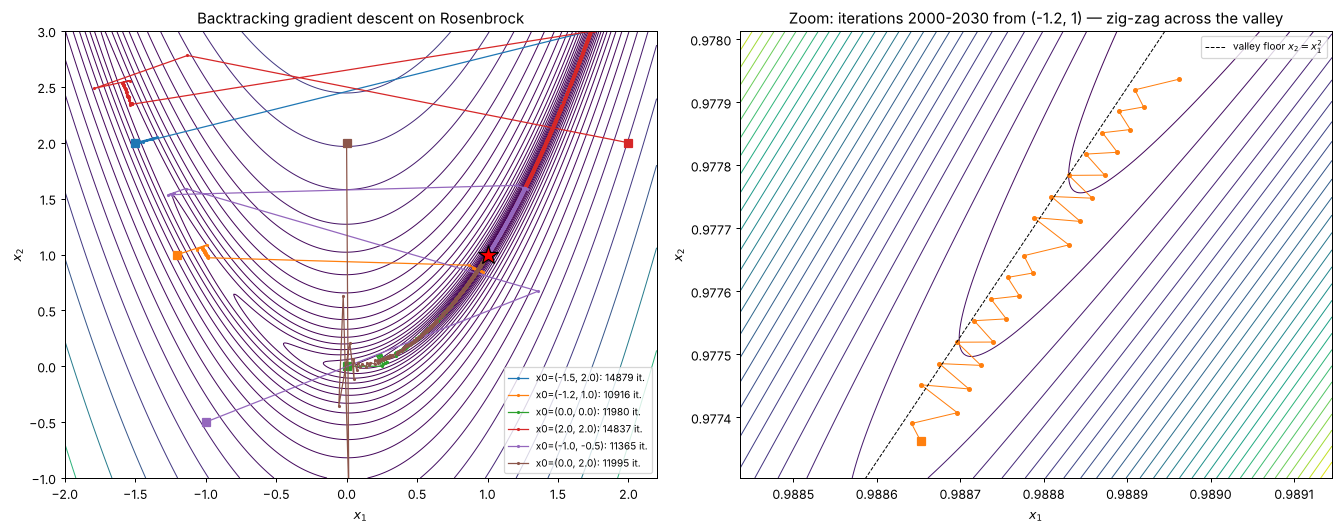

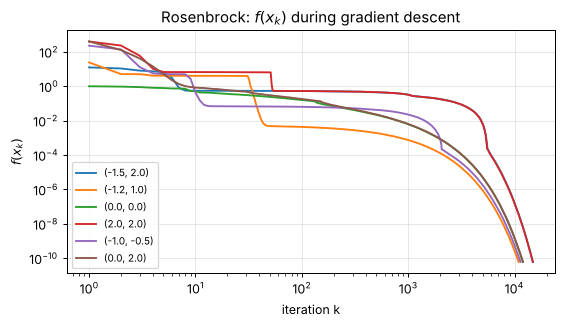

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
contour(f_rosen, (-2, 2.2), (-1, 3), levels=25, ax=axes[0], log=True)
for i, x0 in enumerate(starts_r):
    draw_path(gd_rosen[x0]["path"], axes[0], color=colors[i], label=f"x0={x0}: {gd_rosen[x0]['iters']} it.", ms=1.5)
axes[0].plot(1, 1, "r*", ms=16, mec="k"); axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("Backtracking gradient descent on Rosenbrock")

# zoom on 30 consecutive iterations (k = 2000..2030) from (-1.2, 1) to see the zig-zag
P = gd_rosen[(-1.2, 1.0)]["path"][2000:2031]
cx, cy = P[:, 0].mean(), P[:, 1].mean()
w = max(np.ptp(P[:, 0]), np.ptp(P[:, 1])) * 0.6 + 1e-5
xl, yl = (cx - w, cx + w), (cy - w, cy + w)
Xz, Yz = np.meshgrid(np.linspace(*xl, 300), np.linspace(*yl, 300))
Zz = f_rosen(np.array([Xz, Yz]))
axes[1].contour(Xz, Yz, Zz, levels=np.geomspace(Zz.min() + 1e-12, Zz.max(), 30), cmap="viridis", linewidths=.8)
axes[1].plot(P[:, 0], P[:, 1], "-o", color=colors[1], ms=3, lw=.8)
axes[1].plot(*P[0], "s", color=colors[1], ms=7)
axes[1].plot(xl, np.array(xl)**2, "k--", lw=.8, label="valley floor $x_2=x_1^2$"); axes[1].legend(fontsize=8)
axes[1].set_xlim(*xl); axes[1].set_ylim(*yl); axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")
axes[1].set_title("Zoom: iterations 2000-2030 from (-1.2, 1) — zig-zag across the valley")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.5))
for i, x0 in enumerate(starts_r):
    P = gd_rosen[x0]["path"]
    plt.loglog(np.arange(1, len(P) + 1), [f_rosen(p) for p in P], color=colors[i], label=str(x0))
plt.xlabel("iteration k"); plt.ylabel("$f(x_k)$"); plt.grid(alpha=.3); plt.legend(fontsize=8)
plt.title("Rosenbrock: $f(x_k)$ during gradient descent"); plt.show()

**Answer / interpretation.**

* With the strict criterion $\|\nabla f\|<10^{-5}$ the algorithm **does reach the minimum** $(1,1)$ (error $\approx10^{-5}$) from all starting points, but it needs a huge number of iterations: **of the order of $10^4$** (≈10 000–15 000), compared with ~10 for the camel function.
* The reason is visible in the zoom: the iterates quickly fall to the bottom of the valley (the first few iterations reduce $f$ by orders of magnitude) but then **zig-zag** from one side of the narrow valley to the other, advancing only a tiny distance along it at every step. The gradient is almost perpendicular to the valley, and the step that is acceptable across the valley (high curvature, $\approx 2b$) is far too small to move along it (low curvature). The plot of $f(x_k)$ shows a fast initial drop followed by a very long, slow plateau.

#### Does the stopping criterion guarantee that we are at the minimum?

The statement suggests the alternative criterion $|f(\mathbf{x}_{k+1})-f(\mathbf{x}_k)|<10^{-3}$. Let us use it and check the point that is returned.

In [18]:
print("Stopping criterion |f(x_{k+1}) - f(x_k)| < ftol")
for ftol in [1e-3, 1e-6, 1e-9, 1e-12]:
    print(f"\nftol = {ftol:.0e}")
    for x0 in starts_r:
        r = descent(f_rosen, g_rosen, x0, ftol=ftol)
        print(f"  x0={str(x0):>12s}: {r['iters']:6d} it.  x = {str(r['x'].round(4)):>18s}  "
              f"f = {r['f']:.2e}  ||x - x*|| = {np.linalg.norm(r['x'] - 1):.2e}")

Stopping criterion |f(x_{k+1}) - f(x_k)| < ftol

ftol = 1e-03
  x0= (-1.5, 2.0):     10 it.  x =    [1.7395 3.0281]  f = 5.47e-01  ||x - x*|| = 2.16e+00
  x0= (-1.2, 1.0):     25 it.  x =  [-0.9854  0.9908]  f = 3.98e+00  ||x - x*|| = 1.99e+00
  x0=  (0.0, 0.0):     22 it.  x =    [0.4169 0.1802]  f = 3.44e-01  ||x - x*|| = 1.01e+00
  x0=  (2.0, 2.0):      5 it.  x =  [-1.5881  2.5376]  f = 6.72e+00  ||x - x*|| = 3.01e+00
  x0=(-1.0, -0.5):      7 it.  x =  [-1.2396  1.5357]  f = 5.02e+00  ||x - x*|| = 2.30e+00
  x0=  (0.0, 2.0):     42 it.  x =    [0.4215 0.186 ]  f = 3.42e-01  ||x - x*|| = 9.99e-01

ftol = 1e-06
  x0= (-1.5, 2.0):     66 it.  x =    [1.732  3.0035]  f = 5.37e-01  ||x - x*|| = 2.13e+00
  x0= (-1.2, 1.0):     63 it.  x =    [0.9315 0.8678]  f = 4.69e-03  ||x - x*|| = 1.49e-01
  x0=  (0.0, 0.0):    592 it.  x =    [0.8699 0.757 ]  f = 1.69e-02  ||x - x*|| = 2.76e-01
  x0=  (2.0, 2.0):    151 it.  x =    [1.7223 2.9663]  f = 5.22e-01  ||x - x*|| = 2.09e+00
  x0=(-1.0, -0

  x0=  (0.0, 0.0):   2866 it.  x =    [0.9865 0.9733]  f = 1.82e-04  ||x - x*|| = 2.99e-02


  x0=  (2.0, 2.0):   6971 it.  x =    [1.0045 1.0091]  f = 2.05e-05  ||x - x*|| = 1.01e-02
  x0=(-1.0, -0.5):   2685 it.  x =    [1.0087 1.0174]  f = 7.49e-05  ||x - x*|| = 1.94e-02
  x0=  (0.0, 2.0):   2517 it.  x =    [0.9816 0.9634]  f = 3.42e-04  ||x - x*|| = 4.10e-02

ftol = 1e-12


  x0= (-1.5, 2.0):  11010 it.  x =    [1.0002 1.0004]  f = 3.27e-08  ||x - x*|| = 4.04e-04


  x0= (-1.2, 1.0):   6828 it.  x =    [0.9998 0.9996]  f = 4.67e-08  ||x - x*|| = 4.83e-04
  x0=  (0.0, 0.0):   7568 it.  x =    [0.9997 0.9994]  f = 7.89e-08  ||x - x*|| = 6.27e-04


  x0=  (2.0, 2.0):  10478 it.  x =    [1.0003 1.0005]  f = 7.21e-08  ||x - x*|| = 6.00e-04
  x0=(-1.0, -0.5):   6564 it.  x =    [1.0004 1.0008]  f = 1.49e-07  ||x - x*|| = 8.63e-04


  x0=  (0.0, 2.0):   7162 it.  x =    [0.9996 0.9992]  f = 1.56e-07  ||x - x*|| = 8.83e-04


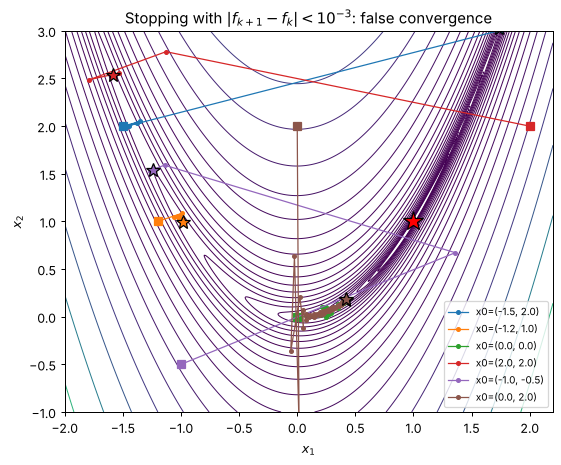

In [19]:
fig, ax = plt.subplots(figsize=(7, 5.5))
contour(f_rosen, (-2, 2.2), (-1, 3), levels=25, ax=ax, log=True)
for i, x0 in enumerate(starts_r):
    r = descent(f_rosen, g_rosen, x0, ftol=1e-3)
    draw_path(r["path"], ax, color=colors[i], ms=3, label=f"x0={x0}")
ax.plot(1, 1, "r*", ms=16, mec="k"); ax.legend(fontsize=8, loc="lower right")
ax.set_title(r"Stopping with $|f_{k+1}-f_k|<10^{-3}$: false convergence")
plt.show()

**Answer / interpretation.**

* With $|f(\mathbf{x}_{k+1})-f(\mathbf{x}_k)|<10^{-3}$ the algorithm stops after only a handful of iterations (≈5–40) at points such as $(1.74, 3.03)$ or $(-1.59, 2.54)$ — **far from the minimum $(1,1)$**. Inside the flat valley $f$ changes very little per iteration even though we are still far from the minimum, so a small change of $f$ is *not* evidence of convergence: the criterion is satisfied but the minimum has not been reached.
* Lowering the threshold progressively brings the final point closer to $(1,1)$, at the price of many more iterations: with $10^{-6}$ some runs are still at distance ≈2 from the minimum, with $10^{-9}$ (≈2 500–7 000 iterations) the error is ≈$10^{-2}$, and with $10^{-12}$ (≈7 000–11 000 iterations) it is ≈$5\cdot10^{-4}$. Only with very small thresholds, or with the gradient criterion $\|\nabla f\|<10^{-5}$, do we actually find the minimum.
* Conclusion: on badly scaled functions the gradient direction is a poor direction, and stopping criteria based on small progress can be misleading. This motivates using directions that take the curvature into account — the Newton direction.

---
# 2. Newton descent method

A general descent method iterates $\mathbf{x}_{k+1}=\mathbf{x}_k+\alpha_k\mathbf{d}_k$. The **Newton direction** comes from minimizing the second-order Taylor model

$$f(\mathbf{x}_k+\mathbf{d}) \approx f(\mathbf{x}_k)+\mathbf{d}^T\nabla f(\mathbf{x}_k)+\tfrac12\mathbf{d}^T\nabla^2 f(\mathbf{x}_k)\,\mathbf{d}.$$

Setting the derivative w.r.t. $\mathbf{d}$ to zero gives the linear system $\nabla^2 f(\mathbf{x}_k)\,\mathbf{d}_k = -\nabla f(\mathbf{x}_k)$. If the Hessian is positive definite, $\mathbf{d}_k^T\nabla f = -\nabla f^T(\nabla^2 f)^{-1}\nabla f<0$, so $\mathbf{d}_k$ is a descent direction. We use the **same backtracking** routine (starting at $\alpha_k=1$, the "natural" Newton step), the same stopping rule and the same starting points as for gradient descent, to make the comparison fair.

## 2.1 A badly scaled quadratic function

$$f(\mathbf{x})=100x_1^2+x_2^2,\qquad \nabla f=(200x_1,\,2x_2)^T,\qquad \nabla^2 f=\begin{pmatrix}200&0\\0&2\end{pmatrix}.$$

The function is convex with a unique minimum at $(0,0)$, but its curvature is 100 times larger in $x_1$ than in $x_2$ (condition number $\kappa = 100$): the level curves are very elongated ellipses.

### Experiments 1–3 — gradient descent vs. Newton

In [20]:
starts_i = [(1.0, 1.0), (-2.0, 3.0), (0.5, -4.0), (1.5, -1.0), (-0.1, 4.5)]
print(f"{'x0':>12s} | {'GD iters':>8s} {'GD f-evals':>10s} {'GD final x':>26s} | {'Newton iters':>12s} {'Newton final x':>16s}")
gd_ill, nw_ill = {}, {}
for x0 in starts_i:
    rg = descent(f_ill, g_ill, x0)
    rn = descent(f_ill, g_ill, x0, hess=h_ill)
    gd_ill[x0], nw_ill[x0] = rg, rn
    print(f"{str(x0):>12s} | {rg['iters']:8d} {rg['nfev']:10d} {str(rg['x']):>26s} | {rn['iters']:12d} {str(rn['x']):>16s}")

          x0 | GD iters GD f-evals                 GD final x | Newton iters   Newton final x
  (1.0, 1.0) |      566       4297        [0.       0.000003] |            1          [0. 0.]
 (-2.0, 3.0) |      611       4638        [0.       0.000004] |            1          [0. 0.]
 (0.5, -4.0) |      625       4743      [-0.       -0.000003] |            1          [0. 0.]
 (1.5, -1.0) |      562       4267      [ 0.       -0.000004] |            1          [0. 0.]
 (-0.1, 4.5) |      629       4772        [0.       0.000003] |            1          [0. 0.]


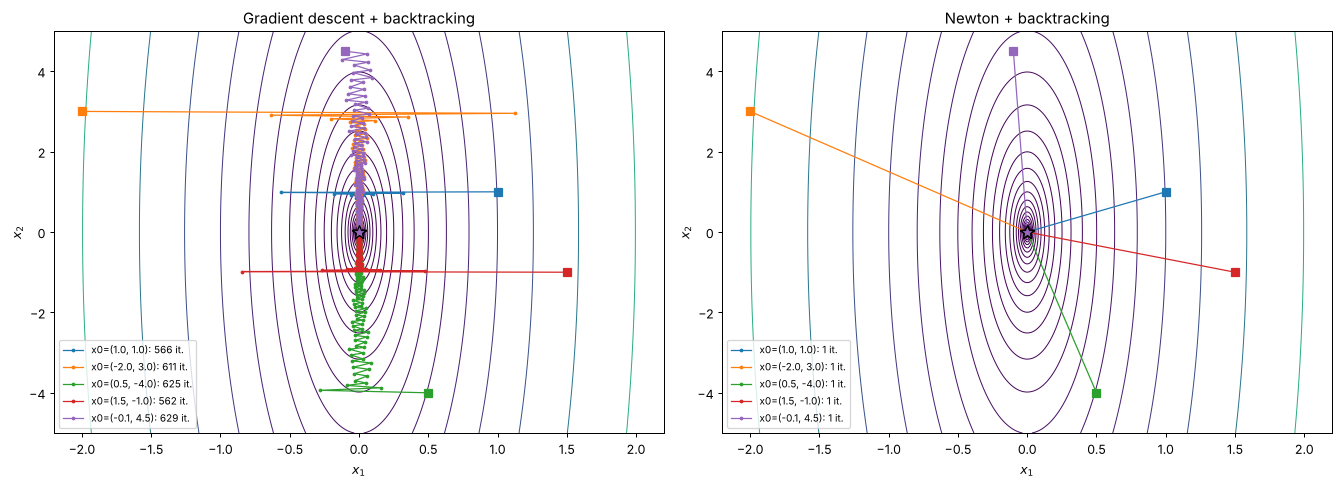

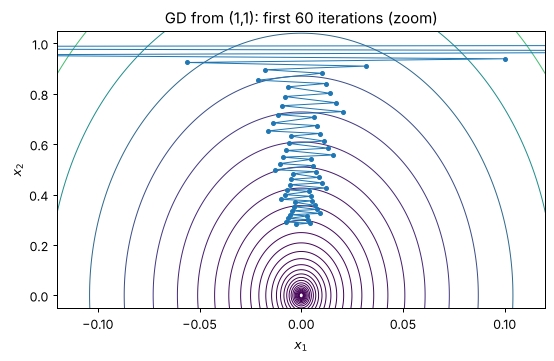

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, res, ttl in [(axes[0], gd_ill, "Gradient descent + backtracking"), (axes[1], nw_ill, "Newton + backtracking")]:
    contour(f_ill, (-2.2, 2.2), (-5, 5), levels=np.logspace(-2, 2.8, 25), ax=ax)
    for i, x0 in enumerate(starts_i):
        draw_path(res[x0]["path"], ax, color=colors[i], ms=2, label=f"x0={x0}: {res[x0]['iters']} it.")
    ax.legend(fontsize=8, loc="lower left"); ax.set_title(ttl)
plt.tight_layout(); plt.show()

# zoom on the gradient-descent zig-zag
fig, ax = plt.subplots(figsize=(7, 4))
P = gd_ill[(1.0, 1.0)]["path"]
contour(f_ill, (-0.12, 0.12), (-0.05, 1.05), levels=np.logspace(-4, 0.5, 30), ax=ax)
ax.plot(P[:60, 0], P[:60, 1], "-o", ms=3, lw=.8, color=colors[0])
ax.set_title("GD from (1,1): first 60 iterations (zoom)"); plt.show()

**Answer / interpretation.**

* **Gradient descent** needs about **570–630 iterations** (and several thousand function evaluations) to satisfy $\|\nabla f\|<10^{-5}$. Because the ellipses are so elongated, $-\nabla f$ points mostly along $x_1$ (the steep direction) instead of towards the centre. Backtracking has to choose a step small enough not to overshoot in $x_1$ (curvature 200, so $\alpha\lesssim 1/100$), and with such a step the progress along $x_2$ (curvature 2) is tiny: the path **zig-zags** across the narrow valley while slowly sliding along it. The ratio of curvatures (condition number) governs this slowness.
* **Newton's method** converges in **exactly one iteration** from every starting point:
$$\mathbf{d}_0=-(\nabla^2 f)^{-1}\nabla f(\mathbf{x}_0) = -\begin{pmatrix}200x_1/200\\ 2x_2/2\end{pmatrix} = -\mathbf{x}_0,$$
so with $\alpha_0=1$ (accepted immediately by backtracking) $\mathbf{x}_1=\mathbf{0}$. For a quadratic function the second-order Taylor model *is* the function, so the Newton step lands on the minimum. Geometrically, multiplying by $(\nabla^2 f)^{-1}$ "rescales" the variables, transforming the elongated ellipses into circles; this is exactly what plain gradient descent lacks.
* The paths plot shows the difference clearly: straight segments for Newton, long zig-zags for gradient descent.

---
## 2.2 The function with multiple minima

For the non-convex camel function the Hessian

$$\nabla^2 f=\begin{pmatrix}8-25.2x_1^2+10x_1^4 & 1\\ 1 & -8+48x_2^2\end{pmatrix}$$

is **not positive definite everywhere** (e.g. at the origin it has eigenvalues of both signs). Where it is not positive definite, the Newton direction may point uphill or towards a saddle/maximum. Hence the **hybrid algorithm** implemented in `descent(..., hess=...)`:

1. At iteration $k$ compute the Hessian analytically and its eigenvalues.
2. If all eigenvalues are $>0$ use the Newton direction, otherwise use the gradient direction $-\nabla f$. In both cases compute $\alpha_k$ with backtracking.

First, let us see where the Hessian is positive definite:

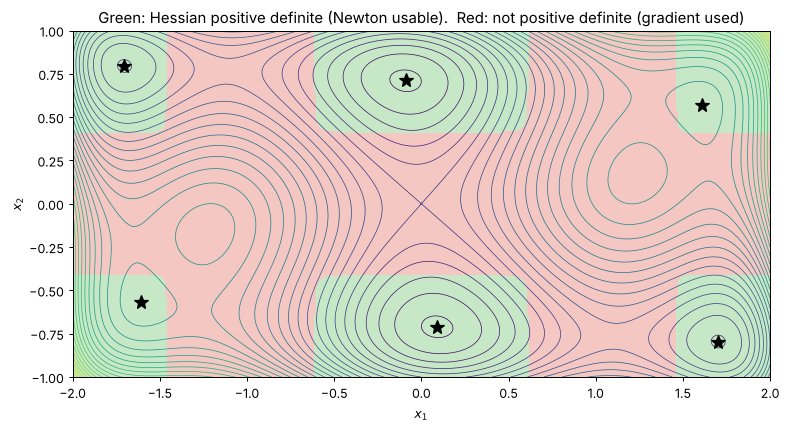

In [22]:
H11 = 8 - 25.2*X**2 + 10*X**4
H22 = -8 + 48*Y**2
pd = (H11 > 0) & (H11*H22 - 1 > 0)          # Sylvester's criterion for a 2x2 matrix
fig, ax = plt.subplots(figsize=(10, 5))
ax.contourf(X, Y, pd, levels=[-0.5, 0.5, 1.5], colors=["#f4c7c3", "#c6e8c6"])
ax.contour(X, Y, Z, levels=40, cmap="viridis", linewidths=0.6)
ax.plot(minima[:, 0], minima[:, 1], "k*", ms=12)
ax.set_title("Green: Hessian positive definite (Newton usable).  Red: not positive definite (gradient used)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); plt.show()

All the minima lie inside green regions (at a strict local minimum the Hessian is positive definite), while the regions around the saddle points and maxima are red.

### Experiments 1–3 — classical gradient descent vs. hybrid Newton–gradient method

We start from the same points as in Section 1.2, including some "far away" from the minima.

In [23]:
starts_h = [(-1.9, -0.9), (-1.0, 0.0), (0.5, 0.2), (1.0, -0.5), (1.9, 0.9), (-0.5, 0.5), (0.0, 0.9), (1.2, 0.0)]
print(f"{'x0':>12s} | {'GD it':>5s} {'GD fev':>6s} {'GD final x':>19s} {'f':>7s} | "
      f"{'Hyb it':>6s} {'fev':>4s} {'#Newton':>7s} {'#GD':>4s} {'Hybrid final x':>19s} {'f':>7s}")
hyb_camel = {}
for x0 in starts_h:
    rg = descent(f_camel, g_camel, x0)
    rh = descent(f_camel, g_camel, x0, hess=h_camel)
    hyb_camel[x0] = (rg, rh)
    nN = rh["methods"].count("Newton")
    print(f"{str(x0):>12s} | {rg['iters']:5d} {rg['nfev']:6d} {str(rg['x'].round(4)):>19s} {rg['f']:7.3f} | "
          f"{rh['iters']:6d} {rh['nfev']:4d} {nN:7d} {rh['iters']-nN:4d} {str(rh['x'].round(4)):>19s} {rh['f']:7.3f}")

          x0 | GD it GD fev          GD final x       f | Hyb it  fev #Newton  #GD      Hybrid final x       f
(-1.9, -0.9) |    11     43   [-0.0898  0.7127]  -1.032 |      5    6       5    0   [-1.6071 -0.5687]   2.104
 (-1.0, 0.0) |    13     51   [ 0.0898 -0.7127]  -1.032 |      6   10       5    1   [-1.7036  0.7961]  -0.215
  (0.5, 0.2) |    16     65   [ 0.0898 -0.7127]  -1.032 |     11   33       4    7   [ 0.0898 -0.7127]  -1.032
 (1.0, -0.5) |    10     43   [-0.0898  0.7127]  -1.032 |      7   12       5    2   [-0.0898  0.7127]  -1.032
  (1.9, 0.9) |    11     43   [ 0.0898 -0.7127]  -1.032 |      5    6       5    0     [1.6071 0.5687]   2.104
 (-0.5, 0.5) |     9     42   [-0.0898  0.7127]  -1.032 |      3    5       3    0   [-0.0898  0.7127]  -1.032
  (0.0, 0.9) |     9     42   [-0.0898  0.7127]  -1.032 |      4    5       4    0   [-0.0898  0.7127]  -1.032
  (1.2, 0.0) |    20     94   [ 1.7036 -0.7961]  -0.215 |      9   25       4    5   [ 1.7036 -0.7961]  -0.215


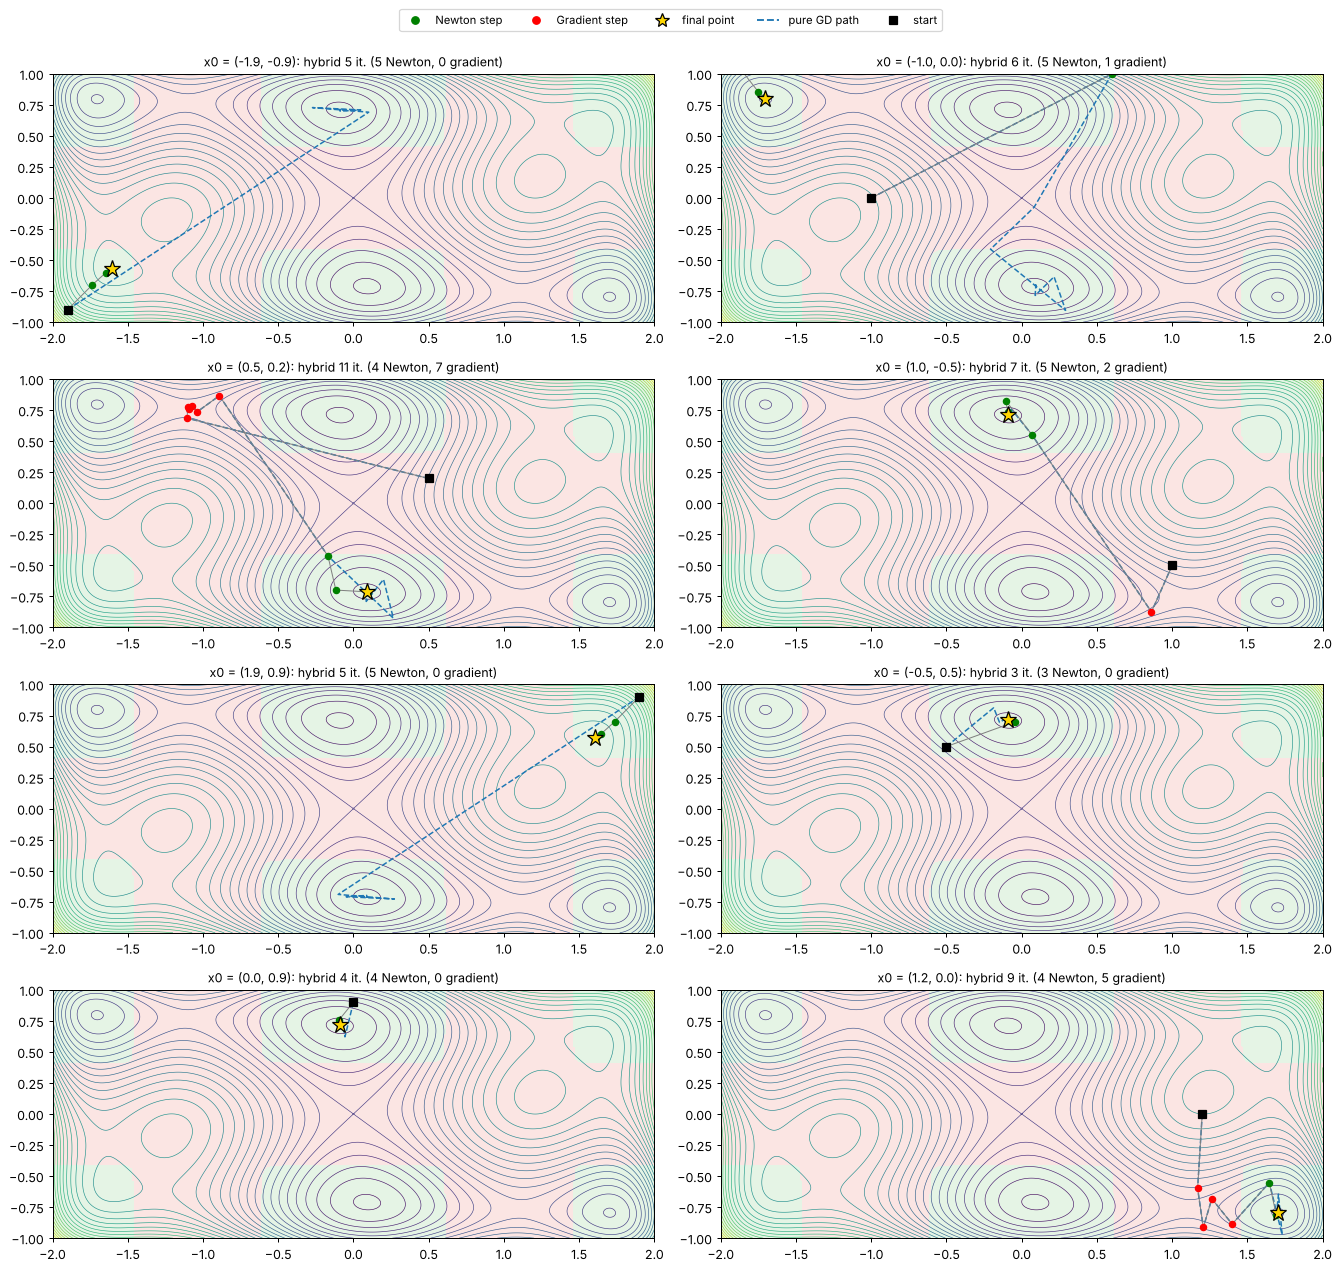

In [24]:
fig, axes = plt.subplots(len(starts_h)//2, 2, figsize=(15, 3.6*len(starts_h)//2))
for ax, x0 in zip(axes.ravel(), starts_h):
    rg, rh = hyb_camel[x0]
    ax.contourf(X, Y, pd, levels=[-0.5, 0.5, 1.5], colors=["#fbe5e3", "#e5f4e5"])
    ax.contour(X, Y, Z, levels=40, cmap="viridis", linewidths=0.5)
    ax.plot(rg["path"][:, 0], rg["path"][:, 1], "--", color="tab:blue", lw=1.2, label=f"GD ({rg['iters']} it.)")
    draw_methods(rh, ax)
    ax.plot(*x0, "ks", ms=7)
    ax.set_xlim(-2, 2); ax.set_ylim(-1, 1)
    ax.set_title(f"x0 = {x0}: hybrid {rh['iters']} it. "
                 f"({rh['methods'].count('Newton')} Newton, {rh['methods'].count('GD')} gradient)", fontsize=10)
fig.legend(handles=method_legend + [Line2D([], [], ls="--", color="tab:blue", label="pure GD path"),
                   Line2D([], [], marker="s", ls="", color="k", label="start")],
           loc="upper center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=(0, 0, 1, 0.98)); plt.show()

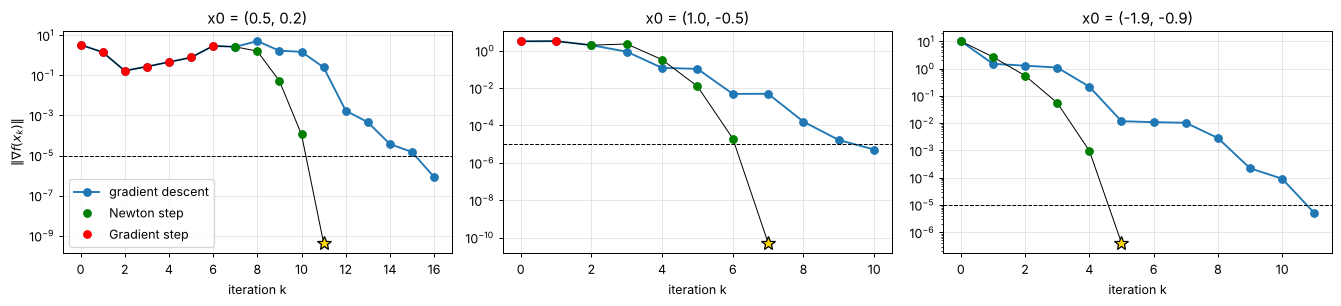

In [25]:
# Convergence speed near the minimum: ||grad f|| per iteration, GD vs hybrid
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, x0 in zip(axes, [(0.5, 0.2), (1.0, -0.5), (-1.9, -0.9)]):
    rg, rh = hyb_camel[x0]
    ax.semilogy([np.linalg.norm(g_camel(p)) for p in rg["path"]], "o-", label="gradient descent")
    gn = [np.linalg.norm(g_camel(p)) for p in rh["path"]]
    ax.semilogy(gn, "k-", lw=.8)
    for i, m in enumerate(rh["methods"]):
        ax.semilogy(i, gn[i], "o", color="green" if m == "Newton" else "red")
    ax.semilogy(len(gn) - 1, gn[-1], "*", color="gold", ms=12, mec="k")
    ax.axhline(1e-5, color="k", ls="--", lw=.8); ax.set_title(f"x0 = {x0}"); ax.set_xlabel("iteration k")
    ax.grid(alpha=.3)
axes[0].legend(handles=[Line2D([], [], marker="o", color="tab:blue", label="gradient descent")] + method_legend[:2])
axes[0].set_ylabel(r"$\|\nabla f(x_k)\|$"); plt.tight_layout(); plt.show()

**Answer / interpretation.**

* **Which method is used where?** Red dots (gradient steps) appear only at the beginning, when the iterate is in a region where the Hessian is indefinite (e.g. from $(0.5,0.2)$, $(1.0,-0.5)$ or $(-1.0,0.0)$, close to the saddle at the origin or to the ridges between valleys). As soon as the iterate enters the convex basin around a minimum (green region), **all the remaining steps are Newton steps** (green dots), exactly as the statement predicts: "near" the minimum the function is locally convex and Newton approaches it very quickly. Starting points already in a green region use Newton from the first iteration.
* **Number of iterations.** The hybrid method needs about **3–11 iterations**, versus about **9–20** for the backtracking gradient descent, and also far fewer function evaluations (5–33 vs. 42–94), because the Newton step $\alpha=1$ is usually accepted at the first trial. The gradient-norm plots show why: gradient descent converges *linearly* (straight line in log scale), while the Newton phase converges *quadratically* — the number of correct digits roughly doubles at each green step, so the last 2–3 iterations take $\|\nabla f\|$ from $10^{-2}$ to below $10^{-10}$.
* **Which minimum?** Both methods remain local: the minimum reached depends on $\mathbf{x}_0$, and the two methods do not always reach the same one (the Newton step with $\alpha=1$ can be long and cross into another basin, as can the first backtracking steps of gradient descent). For instance from $(-1,0)$ the hybrid method converges to $(-1.7036,0.7961)$ while gradient descent goes to the global minimum, and from $(\pm1.9,\pm0.9)$ the hybrid method stays in the outer valley ($f\approx2.10$) while gradient descent jumps to a global minimum. Neither method guarantees finding the global minimum.
* **The point $(0,0)$.** We did not use it as a starting point on purpose: it is a stationary point (a saddle, $\nabla f=\mathbf{0}$), so any gradient-based method stops immediately there. This is another reminder that $\nabla f = 0$ does not imply a minimum.

---
## 2.3 The Rosenbrock function with the hybrid Newton–gradient method

For Rosenbrock ($a=1$, $b=100$)

$$\nabla^2 f=\begin{pmatrix}2-400(x_2-x_1^2)+800x_1^2 & -400x_1\\ -400x_1 & 200\end{pmatrix},$$

and a short computation (Sylvester's criterion) shows that it is positive definite iff $x_2 < 2x_1^2 + 0.005$. So the Hessian is positive definite on the whole valley floor and below, and indefinite above the parabola $x_2 = 2x_1^2$.

### Experiments 1–2 — same starting points as in Section 1.3

In [26]:
print(f"{'x0':>12s} | {'GD iters':>8s} {'GD f-evals':>10s} | {'Hybrid iters':>12s} {'f-evals':>7s} {'#Newton':>7s} {'#GD':>4s} "
      f"{'final x':>22s} {'||x - x*||':>10s}")
hyb_rosen = {}
for x0 in starts_r:
    rg = gd_rosen[x0]
    rh = descent(f_rosen, g_rosen, x0, hess=h_rosen)
    hyb_rosen[x0] = rh
    nN = rh["methods"].count("Newton")
    print(f"{str(x0):>12s} | {rg['iters']:8d} {rg['nfev']:10d} | {rh['iters']:12d} {rh['nfev']:7d} {nN:7d} {rh['iters']-nN:4d} "
          f"{str(rh['x'].round(8)):>22s} {np.linalg.norm(rh['x']-1):10.1e}")

          x0 | GD iters GD f-evals | Hybrid iters f-evals #Newton  #GD                final x ||x - x*||
 (-1.5, 2.0) |    14879     150822 |           22      29      22    0                [1. 1.]    8.8e-10
 (-1.2, 1.0) |    10916     108512 |           21      29      21    0                [1. 1.]    1.4e-10
  (0.0, 0.0) |    11980     118501 |           13      19      13    0                [1. 1.]    5.2e-08
  (2.0, 2.0) |    14837     150355 |           14      20      14    0                [1. 1.]    5.1e-08
(-1.0, -0.5) |    11365     113112 |           19      26      19    0    [0.999999 0.999999]    1.3e-06
  (0.0, 2.0) |    11995     118614 |           15      28      14    1                [1. 1.]    5.5e-08


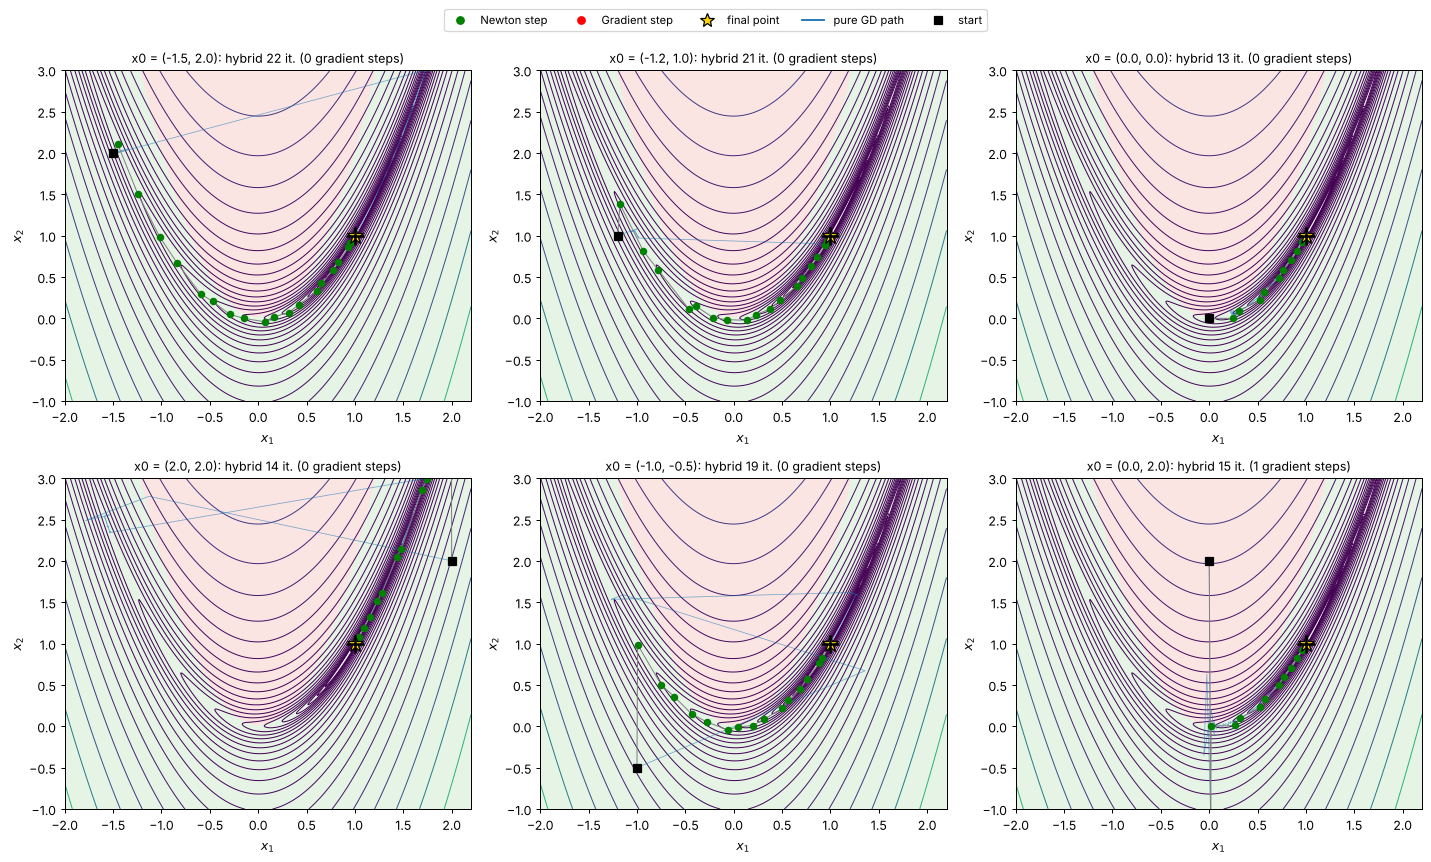

In [27]:
Xr, Yr = np.meshgrid(np.linspace(-2, 2.2, 400), np.linspace(-1, 3, 400))
pd_r = Yr < 2*Xr**2 + 0.005
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, x0 in zip(axes.ravel(), starts_r):
    rh, rg = hyb_rosen[x0], gd_rosen[x0]
    ax.contourf(Xr, Yr, pd_r, levels=[-0.5, 0.5, 1.5], colors=["#fbe5e3", "#e5f4e5"])
    contour(f_rosen, (-2, 2.2), (-1, 3), levels=25, ax=ax, log=True)
    ax.plot(rg["path"][:, 0], rg["path"][:, 1], "-", color="tab:blue", lw=.6, alpha=.6, label=f"GD ({rg['iters']} it.)")
    draw_methods(rh, ax)
    ax.plot(*x0, "ks", ms=7); ax.plot(1, 1, "k+", ms=14, mew=2)
    ax.set_title(f"x0 = {x0}: hybrid {rh['iters']} it. ({rh['methods'].count('GD')} gradient steps)", fontsize=10)
fig.legend(handles=method_legend + [Line2D([], [], color="tab:blue", label="pure GD path"),
                   Line2D([], [], marker="s", ls="", color="k", label="start")],
           loc="upper center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, 1.01))
plt.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

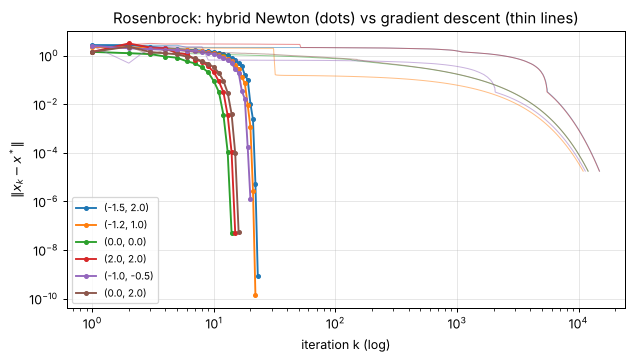

In [28]:
plt.figure(figsize=(8, 4))
for i, x0 in enumerate(starts_r):
    P = hyb_rosen[x0]["path"]; Pg = gd_rosen[x0]["path"]
    plt.semilogy(np.arange(len(Pg)) + 1, [np.linalg.norm(p - 1) for p in Pg], color=colors[i], lw=.8, alpha=.5)
    plt.semilogy(np.arange(len(P)) + 1, [np.linalg.norm(p - 1) for p in P], "o-", color=colors[i], ms=3, label=str(x0))
plt.xscale("log"); plt.xlabel("iteration k (log)"); plt.ylabel(r"$\|x_k - x^*\|$")
plt.title("Rosenbrock: hybrid Newton (dots) vs gradient descent (thin lines)")
plt.legend(fontsize=8); plt.grid(alpha=.3); plt.show()

**Answer / interpretation.**

* **The hybrid Newton method reaches the minimum $(1,1)$ in about 13–22 iterations** (final error between $10^{-10}$ and $10^{-6}$), compared with **≈10 000–15 000 iterations** for the backtracking gradient descent: a reduction of about three orders of magnitude (and similarly in function evaluations, even counting the cost of the Hessian).
* **Which method is used?** Almost all iterations are **Newton steps** (green). A gradient step (red) only appears when the iterate is above the parabola $x_2=2x_1^2$ where the Hessian is indefinite, e.g. at the start from $(0,2)$; after one gradient step the point falls into the region where the Hessian is positive definite, and Newton takes over until convergence.
* **Why does Newton work so much better here?** Gradient descent ignores the shape of the valley and keeps jumping from one side to the other. The Newton direction uses the curvature information of the Hessian: it effectively rescales the variables so that the narrow curved valley looks locally "round", and the step points *along* the valley towards the minimum. The path follows the bottom of the banana-shaped valley in a few long steps (sometimes backtracking reduces $\alpha$ when the quadratic model is not accurate far from the minimum), and close to $(1,1)$ the convergence becomes quadratic.

---
# 3. Conclusions

| Problem | Gradient descent (backtracking) | Hybrid Newton–gradient (backtracking) |
|---|---|---|
| $x_1^2+x_2^2$ (constant $\alpha$) | converges iff $0<\alpha<1$; $\alpha=0.1$: error $\times0.8$ per iteration | — |
| $100x_1^2+x_2^2$ | ≈ 600 iterations, zig-zag | **1 iteration** (exact for quadratics) |
| Six-hump camel | ≈ 8–20 iterations (constant $\alpha=0.1$: 11–30, may oscillate) | ≈ 3–11 iterations; Newton near the minima |
| Rosenbrock | ≈ 10⁴ iterations; false convergence with $\lvert\Delta f\rvert<10^{-3}$ | ≈ 13–22 iterations, minimum found |

Main take-aways:

1. **Why gradient descent works:** $-\nabla f$ is the direction of steepest local decrease, so with a small enough step $f$ always decreases; it only needs first derivatives and each iteration is cheap.
2. **The step matters.** A constant step that is too large oscillates or diverges, one that is too small is slow. Backtracking (start with $\alpha=1$ and halve until $f$ decreases) adapts the step automatically and guarantees monotone decrease.
3. **When gradient descent is a good method:** on well-scaled problems (round level curves, e.g. $x_1^2+x_2^2$). On badly scaled problems ($100x_1^2+x_2^2$, Rosenbrock) it zig-zags and needs hundreds or thousands of iterations; the slowdown is governed by the ratio between the largest and smallest curvatures.
4. **Local methods.** For non-convex functions both methods converge to a local minimum that depends on the starting point (and on the step rule); neither guarantees the global minimum, and both stop at any stationary point (e.g. a saddle).
5. **Stopping criteria** must be chosen carefully: a small change of $f$ does not imply that the minimum has been reached (Rosenbrock with $|\Delta f|<10^{-3}$). The gradient norm is a more reliable test.
6. **Newton's method** uses second-order information (the Hessian) and converges in far fewer iterations (quadratically near the minimum, in one step for quadratics). Its drawbacks are the cost of computing the Hessian and solving $\nabla^2 f\,\mathbf{d}=-\nabla f$ (prohibitive for very many variables), and that $\mathbf{d}$ is a descent direction only when the Hessian is positive definite — hence the hybrid strategy (or truncated Newton, quasi-Newton methods such as L-BFGS). For very large problems such as training machine-learning models, even full gradient descent is too expensive and stochastic gradient methods (SGD, Adam) are used instead.